In [1]:
# ============================================================
# SECTION 1 — Install dependencies
# ============================================================
!pip -q install spacy faker tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.3 MB/s eta 0:00:00


In [64]:
# ============================================================
# SECTION 2 — Imports and configuration
# ============================================================
import os, re, json, random, string, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from faker import Faker
import spacy
from spacy.tokens import DocBin
from google.colab import files

warnings.filterwarnings("ignore")

random.seed(42)
np.random.seed(42)
fake = Faker()

CONFIG = {
    "OUTPUT_DIR": "/content/redaction_preprocessed",
    "SAVE_DOCBIN": True
}

Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)

In [65]:
# ============================================================
# CONFIGURATION
# ============================================================
CONFIG = {
    "INPUT_FILENAME_CANDIDATES": [
        "NER dataset.csv",
        "ner_dataset.csv",
        "ner.csv"
    ],
    "OUTPUT_DIR": "/content/redaction_preprocessed",

    # AUGMENTATION
    "AUGMENT_CASE_VARIANTS": True,
    "AUGMENT_SINGLE_NAME_PERSON": True,
    "AUGMENT_LOWERCASE_CONTEXT": True,
    "AUGMENT_MISSING_REDACTION_LABELS": True,

    "MAX_SINGLE_NAME_SAMPLES": 4000,

    # BALANCING (FIXED TIME)
    "SYNTHETIC_SAMPLES_PER_LABEL": {
        "PERSON": 250,
        "ORGANIZATION": 200,
        "LOCATION": 150,
        "GPE": 150,
        "DATE": 200,
        "TIME": 600,
    },

    # EXPORT
    "SAVE_DOCBIN": True,
    "DOCBIN_NAME": "redaction_train.spacy",
    "CLEANED_TOKEN_CSV_NAME": "cleaned_token_level.csv",
    "SENTENCE_CSV_NAME": "cleaned_sentence_level.csv",
    "SPACY_JSON_NAME": "spacy_redaction_data.json",
    "SPACY_JSONL_NAME": "spacy_redaction_data.jsonl",
}

Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)

In [70]:
# ============================================================
# SECTION 3 — Load dataset from Google Drive
# ============================================================

from google.colab import drive
import os

# ---------------------------
# SET FILE PATH HERE
# ---------------------------
INPUT_CSV = "/content/NER_raw.csv"

# ---------------------------
# Validate path
# ---------------------------
if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(f"File not found: {INPUT_CSV}")

print("Using dataset:", INPUT_CSV)

Using dataset: /content/NER_raw.csv


In [71]:
# ============================================================
# SECTION 4 — Load dataset
# ============================================================
df = pd.read_csv(INPUT_CSV, encoding="latin")

df.columns = [c.strip() for c in df.columns]
df.rename(columns={
    "Sentence #": "Sentence #",
    "Word": "Word",
    "POS": "POS",
    "Tag": "Tag"
}, inplace=True)

df["Sentence #"] = df["Sentence #"].ffill()

In [72]:
# ============================================================
# SECTION 5 — Clean tokens (ROW COUNT BEFORE/AFTER)
# ============================================================

rows_before = len(df)

def clean_word(x):
    if pd.isna(x):
        return ""

    x = str(x)
    x = x.replace("\u200b", "").replace("\xa0", " ")

    replacements = {
        "``": '"',
        "''": '"',
        "`": "'"
    }
    x = replacements.get(x, x)

    return x.strip()


def clean_tag(x):
    if pd.isna(x):
        return "O"
    return str(x).strip().upper()


def clean_pos(x):
    if pd.isna(x):
        return "UNK"
    return str(x).strip().upper()


# Apply cleaning
df["Word"] = df["Word"].apply(clean_word)
df["Tag"] = df["Tag"].apply(clean_tag)

if "POS" in df.columns:
    df["POS"] = df["POS"].apply(clean_pos)

# Drop empty tokens
df = df[df["Word"].str.len() > 0].copy()

rows_after = len(df)

# ---------------------------
# SUMMARY
# ---------------------------
print("\n📊 CLEANING SUMMARY")
print(f"Rows before: {rows_before}")
print(f"Rows after : {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")


📊 CLEANING SUMMARY
Rows before: 1048575
Rows after : 1048561
Rows removed: 14


In [73]:
# ============================================================
# SECTION 6 — LABEL NORMALIZATION (ROBUST)
# ============================================================

LABEL_MAP = {
    "per": "PERSON",
    "org": "ORGANIZATION",
    "geo": "LOCATION",
    "gpe": "LOCATION",
    "loc": "LOCATION",
    "tim": "DATETIME",
}

NER_LABELS = {
    "PERSON",
    "ORGANIZATION",
    "LOCATION",
    "DATE",
    "TIME"
}

REGEX_LABELS = {
    "EMAIL","PHONE","CREDIT_CARD","ID","PASSPORT",
    "IP_ADDRESS","URL_TOKEN","MONEY","PERCENT"
}


# ---------------------------
# Safe tag splitting
# ---------------------------
def split_tag(tag):
    tag = str(tag).strip().upper()

    if tag == "O":
        return "O", "O"

    if "-" not in tag:
        return "B", tag  # fallback

    b, t = tag.split("-", 1)
    t = LABEL_MAP.get(t.lower(), t.upper())

    return b, t


df["BIO"], df["TYPE"] = zip(*df["Tag"].apply(split_tag))


# ============================================================
# DATETIME CLASSIFICATION
# ============================================================

DATE_KEYWORDS = [
    "january","feb","march","april","may","june","july",
    "august","september","october","november","december",
    "monday","tuesday","wednesday","thursday","friday",
    "saturday","sunday"
]

def classify_datetime(text):
    t = text.lower()

    # TIME patterns
    if re.search(r"\d{1,2}:\d{2}", t):
        return "TIME"

    if any(k in t for k in ["am", "pm"]):
        return "TIME"

    # DATE patterns
    if any(k in t for k in DATE_KEYWORDS):
        return "DATE"

    if re.match(r"\d{4}-\d{2}-\d{2}", t):
        return "DATE"

    if re.match(r"\d{1,2}[/-]\d{1,2}[/-]\d{2,4}", t):
        return "DATE"

    if re.match(r"\d{4}", t):
        return "DATE"

    return "DATE"


# ============================================================
# DEBUG — LABEL DISTRIBUTION AFTER NORMALIZATION
# ============================================================

print("\n📊 Label distribution after normalization:")

label_counts = Counter(df["TYPE"])

for k, v in label_counts.most_common():
    print(k, ":", v)


📊 Label distribution after normalization:
O : 887894
LOCATION : 61126
ORGANIZATION : 36927
PERSON : 34241
DATETIME : 26861
ART : 699
EVE : 561
NAT : 252


In [74]:
# ============================================================
# SECTION 7 — Build sentences + spans (ROBUST)
# ============================================================

NO_SPACE_BEFORE = {".", ",", "!", "?", ";", ":", "%", ")", "]", "}", "'s", "n't"}
NO_SPACE_AFTER = {"(", "[", "{", "$", "#", '"'}

def should_add_space(prev_token, token):
    if prev_token is None:
        return False
    if token in NO_SPACE_BEFORE:
        return False
    if prev_token in NO_SPACE_AFTER:
        return False
    return True


sentences = []

for sid, group in tqdm(df.groupby("Sentence #"), desc="Building sentences"):

    words = group["Word"].tolist()
    bios = group["BIO"].tolist()
    types = group["TYPE"].tolist()

    text_parts = []
    token_starts = []
    token_ends = []

    current_len = 0
    prev_tok = None

    # ---------------------------
    # Build text + offsets safely
    # ---------------------------
    for tok in words:
        tok = str(tok)

        if should_add_space(prev_tok, tok):
            text_parts.append(" ")
            current_len += 1

        token_starts.append(current_len)

        text_parts.append(tok)
        current_len += len(tok)

        token_ends.append(current_len)

        prev_tok = tok

    text = "".join(text_parts)

    # ---------------------------
    # Build entities
    # ---------------------------
    entities = []
    current_start = None
    current_end = None
    current_type = None

    for i in range(len(words)):

        bio = bios[i]
        typ = types[i]

        start = token_starts[i]
        end = token_ends[i]

        # DATETIME split
        if typ == "DATETIME":
            entity_text = text[start:end]
            typ = classify_datetime(entity_text)

        if bio == "B":
            if current_type is not None:
                entities.append((current_start, current_end, current_type))

            current_start = start
            current_end = end
            current_type = typ

        elif bio == "I" and current_type == typ:
            current_end = end

        else:
            if current_type is not None:
                entities.append((current_start, current_end, current_type))

            current_start = None
            current_end = None
            current_type = None

    if current_type is not None:
        entities.append((current_start, current_end, current_type))

    # ---------------------------
    # Validate spans
    # ---------------------------
    clean_entities = []
    for s, e, l in entities:
        if s < e and e <= len(text):
            clean_entities.append((s, e, l))

    sentences.append((text, {"entities": clean_entities}))

Building sentences:   0%|          | 0/47959 [00:00<?, ?it/s]

In [75]:
# ============================================================
# SECTION 8 — CLEAN BAD ANNOTATIONS (FIXED)
# ============================================================

BAD_LABEL_FIXES = {
    "red cross": "ORGANIZATION",
    "western sahara": "LOCATION"
}

cleaned = []

for text, ann in sentences:

    new_ents = []

    for s, e, l in ann["entities"]:

        entity_text = text[s:e].lower().strip()

        # ---------------------------
        # Normalize known bad labels
        # ---------------------------
        for key, fixed_label in BAD_LABEL_FIXES.items():
            if key in entity_text:
                l = fixed_label
                break

        # ---------------------------
        # Keep only valid NER labels
        # ---------------------------
        if l in NER_LABELS:
            new_ents.append((s, e, l))

    cleaned.append((text, {"entities": new_ents}))

In [76]:
# ============================================================
# SECTION 9 — AUGMENTATION (UNIFIED & FINAL)
# ============================================================

def transform_case(text, entities, mode):
    if mode == "lower":
        new_text = text.lower()
    elif mode == "upper":
        new_text = text.upper()
    elif mode == "title":
        new_text = text.title()
    else:
        return text, entities

    # safe: offsets remain valid (length unchanged)
    return new_text, entities


def generate_noisy_person(name):
    return [
        f"hey my name is {name.lower()}",
        f"pls contact {name.lower()} asap",
    ]


augmented = []

for text, ann in cleaned:

    entities = ann["entities"]

    # ---------------------------
    # ORIGINAL
    # ---------------------------
    augmented.append((text, {"entities": entities}))

    # ---------------------------
    # CASE AUGMENTATION
    # ---------------------------
    if CONFIG.get("AUGMENT_CASE_VARIANTS", True):
        for mode in ["lower", "upper", "title"]:
            new_text, new_entities = transform_case(text, entities, mode)
            augmented.append((new_text, {"entities": new_entities}))

    # ---------------------------
    # NOISY PERSON AUGMENTATION
    # ---------------------------
    if CONFIG.get("AUGMENT_LOWERCASE_CONTEXT", True):
        for s, e, l in entities:
            if l == "PERSON":
                name = text[s:e]

                for noisy in generate_noisy_person(name):
                    start = noisy.find(name.lower())

                    if start != -1:
                        end = start + len(name)

                        augmented.append((
                            noisy,
                            {"entities": [(start, end, "PERSON")]}
                        ))

print("Augmented samples:", len(augmented))

Augmented samples: 225794


In [77]:
# ============================================================
# SECTION 10 — HARD NEGATIVES (UNIFIED & IMPROVED)
# ============================================================

hard_negatives = [
    # email-like but NOT email
    ("email me the report", {"entities": []}),

    # phone-like intent but no number
    ("call me maybe", {"entities": []}),

    # name-like but not entity
    ("the word johnny is here", {"entities": []}),

    # common word confusion
    ("apple is tasty", {"entities": []}),

    # ambiguous DATE keyword
    ("may is a nice month", {"entities": []}),

    # additional useful negatives
    ("send the file asap", {"entities": []}),
    ("this is just a random sentence", {"entities": []}),
    ("contact support team", {"entities": []}),
]

# Add to dataset
augmented.extend(hard_negatives)

print("Added hard negatives:", len(hard_negatives))

Added hard negatives: 8


In [78]:
# ============================================================
# SECTION 11 — REGEX synthetic samples (EXPANDED)
# ============================================================

def regex_sample(label, value):
    text = f"Sensitive: {value}"
    s = text.index(value)
    return (text, {"entities": [(s, s + len(value), label)]})


def generate_regex_samples(n=50):
    samples = []

    for _ in range(n):

        samples.extend([
            regex_sample("EMAIL", f"user{random.randint(1,999)}@example.com"),
            regex_sample("PHONE", f"+974 {random.randint(3000,7999)} {random.randint(1000,9999)}"),
            regex_sample("CREDIT_CARD", f"{random.randint(1000,9999)}-{random.randint(1000,9999)}-{random.randint(1000,9999)}-{random.randint(1000,9999)}"),
            regex_sample("IP_ADDRESS", f"{random.randint(1,255)}.{random.randint(1,255)}.{random.randint(1,255)}.{random.randint(1,255)}"),
            regex_sample("MONEY", f"${random.randint(10,9999)}"),
            regex_sample("PERCENT", f"{random.randint(1,100)}%"),
            regex_sample("URL_TOKEN", f"https://api.test.com?token={random.randint(10000,99999)}"),
            regex_sample("ID", f"ID{random.randint(10000,99999)}"),
            regex_sample("PASSPORT", f"A{random.randint(1000000,9999999)}"),
        ])

    return samples


# Generate
regex_data = generate_regex_samples(n=30)

# Add to dataset
augmented.extend(regex_data)

print("Added regex samples:", len(regex_data))

Added regex samples: 270


In [79]:
# ============================================================
# SECTION 12 — TIME AUGMENTATION (CLEAN)
# ============================================================

def generate_time_variants(n=4000):

    templates = [
        "The meeting is at {t}.",
        "Call me at {t}.",
        "The event starts at {t}.",
        "The time is {t}.",
        "Arrival time: {t}.",
    ]

    time_values = [
        "10:30 AM",
        "14:45",
        "9 pm",
        "08:15 a.m.",
        "23:59",
        "12:00 PM",
    ]

    examples = []

    for _ in range(n):
        t = random.choice(time_values)
        template = random.choice(templates)

        text = template.format(t=t)
        start = text.index(t)
        end = start + len(t)

        examples.append((text, {"entities": [(start, end, "TIME")]}))

    return examples


# Add TIME samples BEFORE dedup
time_augmented = generate_time_variants(n=4000)
augmented.extend(time_augmented)

print("Generated TIME samples:", len(time_augmented))

Generated TIME samples: 4000


In [80]:
# ============================================================
# SECTION 13 — FINAL DEDUP + VALIDATION (FIXED)
# ============================================================

def validate_entities(text, ents):
    valid = []
    seen_spans = set()

    for s, e, l in ents:

        # ---------------------------
        # Basic checks
        # ---------------------------
        if not isinstance(s, int) or not isinstance(e, int):
            continue

        if s < 0 or e <= s or e > len(text):
            continue

        span_text = text[s:e].strip()

        if span_text == "":
            continue

        key = (s, e, l)

        if key not in seen_spans:
            seen_spans.add(key)
            valid.append((s, e, l))

    return valid


final_data = []
seen_examples = set()

for text, ann in augmented:

    ents = validate_entities(text, ann["entities"])

    key = (text, tuple(ents))

    if key not in seen_examples:
        seen_examples.add(key)
        final_data.append((text, {"entities": ents}))


print("Final examples:", len(final_data))

Final examples: 203185


In [82]:
# ============================================================
# SECTION 14 — DATASET STATS (FINAL)
# ============================================================

from collections import Counter

counter = Counter()

for _, ann in final_data:
    for _, _, label in ann["entities"]:
        counter[label] += 1

print("\n📊 Entity distribution:")
for label, count in counter.most_common():
    print(f"{label} : {count}")

print("\nTotal examples:", len(final_data))
print("Total entities:", sum(counter.values()))


📊 Entity distribution:
LOCATION : 213047
DATE : 80875
ORGANIZATION : 80272
PERSON : 80056
TIME : 134
EMAIL : 30
PHONE : 30
CREDIT_CARD : 30
IP_ADDRESS : 30
MONEY : 30
URL_TOKEN : 30
ID : 30
PASSPORT : 30
PERCENT : 25

Total examples: 203185
Total entities: 454649


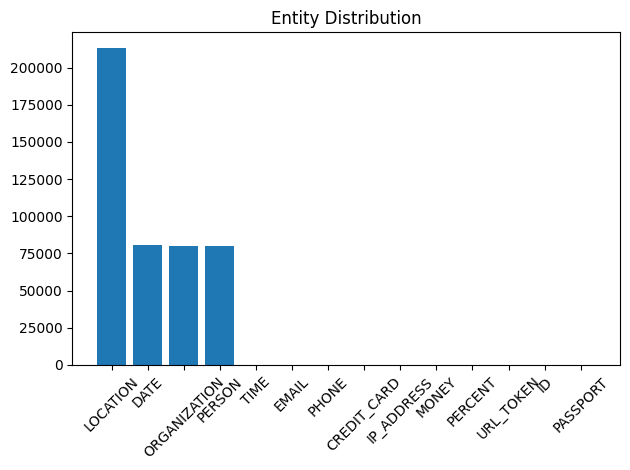


Sentence length stats:
Min: 1
Max: 80
Mean: 18.98

Entity length stats:
Min: 1
Max: 10
Mean: 1.45

Overlapping spans: 0
Duplicate sentences: 120

Sample TIME examples:
('This year Ramadan begins amid scorching temperatures in the Middle East and elsewhere, with the first six months of 2010 being the warmest ever recorded.', {'entities': [(10, 17, 'TIME'), (60, 71, 'LOCATION'), (96, 105, 'DATE'), (113, 120, 'DATE')]})
('this year ramadan begins amid scorching temperatures in the middle east and elsewhere, with the first six months of 2010 being the warmest ever recorded.', {'entities': [(10, 17, 'TIME'), (60, 71, 'LOCATION'), (96, 105, 'DATE'), (113, 120, 'DATE')]})
('THIS YEAR RAMADAN BEGINS AMID SCORCHING TEMPERATURES IN THE MIDDLE EAST AND ELSEWHERE, WITH THE FIRST SIX MONTHS OF 2010 BEING THE WARMEST EVER RECORDED.', {'entities': [(10, 17, 'TIME'), (60, 71, 'LOCATION'), (96, 105, 'DATE'), (113, 120, 'DATE')]})
('This Year Ramadan Begins Amid Scorching Temperatures In The Middle Eas

In [83]:
# ============================================================
# SECTION 15 — EDA (DATA QUALITY + DISTRIBUTION)
# ============================================================

import matplotlib.pyplot as plt

# ---------------------------
# 1. Entity Distribution Plot
# ---------------------------
labels = list(counter.keys())
counts = list(counter.values())

plt.figure()
plt.bar(labels, counts)
plt.xticks(rotation=45)
plt.title("Entity Distribution")
plt.tight_layout()
plt.show()


# ---------------------------
# 2. Sentence Length Analysis
# ---------------------------
lengths = [len(text.split()) for text, _ in final_data]

print("\nSentence length stats:")
print("Min:", int(np.min(lengths)))
print("Max:", int(np.max(lengths)))
print("Mean:", round(np.mean(lengths), 2))


# ---------------------------
# 3. Entity Length Analysis
# ---------------------------
entity_lengths = []

for text, ann in final_data:
    for s, e, l in ann["entities"]:
        entity_lengths.append(len(text[s:e].split()))

if entity_lengths:
    print("\nEntity length stats:")
    print("Min:", int(np.min(entity_lengths)))
    print("Max:", int(np.max(entity_lengths)))
    print("Mean:", round(np.mean(entity_lengths), 2))
else:
    print("\nNo entities found.")


# ---------------------------
# 4. Check Label Overlaps
# ---------------------------
overlap_count = 0

for text, ann in final_data:
    spans = sorted(ann["entities"], key=lambda x: x[0])

    for i in range(len(spans) - 1):
        if spans[i][1] > spans[i + 1][0]:
            overlap_count += 1

print("\nOverlapping spans:", overlap_count)


# ---------------------------
# 5. Duplicate Text Check
# ---------------------------
texts = [text for text, _ in final_data]
duplicates = len(texts) - len(set(texts))

print("Duplicate sentences:", duplicates)


# ---------------------------
# 6. Rare Entity Examples (TIME)
# ---------------------------
print("\nSample TIME examples:")

time_samples = [
    (text, ann)
    for text, ann in final_data
    if any(e[2] == "TIME" for e in ann["entities"])
]

for i in range(min(5, len(time_samples))):
    print(time_samples[i])


# ---------------------------
# 7. Class Imbalance Check (VERY IMPORTANT)
# ---------------------------
print("\n⚖️ Class ratios vs max:")

max_count = max(counter.values())

for label, count in counter.items():
    ratio = round(count / max_count, 2)
    print(f"{label}: {ratio}")

In [84]:
# ============================================================
# SECTION 16 — AUTO BALANCER (FINAL)
# ============================================================

from collections import defaultdict

TARGET_RATIOS = {
    "LOCATION": 1.0,
    "PERSON": 0.45,
    "ORGANIZATION": 0.40,
    "DATE": 0.40,
    "TIME": 0.25   # 🔥 slightly higher for safety
}


def compute_label_counts(data):
    counter = Counter()
    for _, ann in data:
        for _, _, l in ann["entities"]:
            counter[l] += 1
    return counter


def index_by_label(data):
    label_to_samples = defaultdict(list)

    for item in data:
        labels = set(l for _, _, l in item[1]["entities"])
        for l in labels:
            label_to_samples[l].append(item)

    return label_to_samples


def auto_balance_dataset(data, target_ratios):

    print("\n🔧 Running auto-balancer...")

    label_counts = compute_label_counts(data)
    label_index = index_by_label(data)

    anchor_label = max(label_counts, key=label_counts.get)
    anchor_count = label_counts[anchor_label]

    print(f"Anchor label: {anchor_label} ({anchor_count})")

    new_data = list(data)

    for label, ratio in target_ratios.items():

        if label not in label_counts:
            continue

        target_count = int(anchor_count * ratio)
        current_count = label_counts[label]

        print(f"\n{label}: {current_count} → {target_count}")

        samples = label_index[label]

        # -------------------------
        # UPSAMPLE ONLY (SAFE)
        # -------------------------
        if current_count < target_count:
            needed = target_count - current_count

            for _ in range(needed):
                new_data.append(random.choice(samples))

    print("\n✅ Balancing complete")
    return new_data


# ⚠️ APPLY AFTER final_data is built
final_data = auto_balance_dataset(final_data, TARGET_RATIOS)


# ---------------------------
# Show distribution
# ---------------------------
counter = compute_label_counts(final_data)

print("\n📊 Balanced distribution:")
for k, v in counter.most_common():
    print(k, ":", v)


🔧 Running auto-balancer...
Anchor label: LOCATION (213047)

LOCATION: 213047 → 213047

PERSON: 80056 → 95871

ORGANIZATION: 80272 → 85218

DATE: 80875 → 85218

TIME: 134 → 53261

✅ Balancing complete

📊 Balanced distribution:
LOCATION : 281956
PERSON : 129591
DATE : 120099
ORGANIZATION : 111897
TIME : 53268
EMAIL : 30
PHONE : 30
CREDIT_CARD : 30
IP_ADDRESS : 30
MONEY : 30
URL_TOKEN : 30
ID : 30
PASSPORT : 30
PERCENT : 25


In [85]:
# ============================================================
# SECTION 17 — POST-BALANCE STATS
# ============================================================

counter = compute_label_counts(final_data)

print("\n📊 POST-BALANCE DISTRIBUTION:")
for k, v in counter.most_common():
    print(k, ":", v)

print("\n⚖️ Ratios vs max:")
max_count = max(counter.values())

for label, count in counter.items():
    print(f"{label}: {round(count / max_count, 2)}")


📊 POST-BALANCE DISTRIBUTION:
LOCATION : 281956
PERSON : 129591
DATE : 120099
ORGANIZATION : 111897
TIME : 53268
EMAIL : 30
PHONE : 30
CREDIT_CARD : 30
IP_ADDRESS : 30
MONEY : 30
URL_TOKEN : 30
ID : 30
PASSPORT : 30
PERCENT : 25

⚖️ Ratios vs max:
LOCATION: 1.0
DATE: 0.43
ORGANIZATION: 0.4
PERSON: 0.46
TIME: 0.19
EMAIL: 0.0
PHONE: 0.0
CREDIT_CARD: 0.0
IP_ADDRESS: 0.0
MONEY: 0.0
PERCENT: 0.0
URL_TOKEN: 0.0
ID: 0.0
PASSPORT: 0.0


In [86]:
# ============================================================
# SECTION 18 — NER-only dataset (FIXED)
# ============================================================

def filter_ner(data, keep_empty=True, max_empty_ratio=0.3):

    ner_data = []
    empty_samples = []

    for text, ann in data:
        ents = [(s, e, l) for s, e, l in ann["entities"] if l in NER_LABELS]

        if len(ents) == 0:
            empty_samples.append((text, {"entities": []}))
        else:
            ner_data.append((text, {"entities": ents}))

    # ---------------------------
    # Control empty samples ratio
    # ---------------------------
    if keep_empty:
        max_empty = int(len(ner_data) * max_empty_ratio)
        empty_samples = empty_samples[:max_empty]
        ner_data.extend(empty_samples)

    print("\n📊 NER DATASET STATS:")
    print("Total samples:", len(ner_data))
    print("Empty samples:", len(empty_samples))

    return ner_data


# Apply filter
ner_data = filter_ner(final_data)


📊 NER DATASET STATS:
Total samples: 281416
Empty samples: 28379


In [87]:
# ============================================================
# SECTION 19 — FINAL DATA QUALITY ASSERTIONS (UNIFIED & FINAL)
# ============================================================

import re
from collections import Counter

print("\n🔍 Running final dataset validation...\n")

# ---------------------------
# 1. Basic integrity
# ---------------------------
assert isinstance(final_data, list), "final_data must be a list"
assert len(final_data) > 0, "Dataset is empty"

print("✅ Dataset exists and is non-empty")


# ---------------------------
# 2. Text checks
# ---------------------------
assert all(text.strip() for text, _ in final_data), "Empty text found"

double_spaces = sum(1 for text,_ in final_data if "  " in text)
print("Double-space texts:", double_spaces)

print("✅ Texts valid")


# ---------------------------
# 3. Span validation
# ---------------------------
invalid_spans = 0

for text, ann in final_data:
    for start, end, label in ann["entities"]:

        if not isinstance(start, int) or not isinstance(end, int):
            invalid_spans += 1

        if start < 0 or end <= start or end > len(text):
            invalid_spans += 1

        if text[start:end].strip() == "":
            invalid_spans += 1

assert invalid_spans == 0, f"Invalid spans found: {invalid_spans}"

print("✅ All spans valid")


# ---------------------------
# 4. Overlapping spans
# ---------------------------
overlaps = 0

for text, ann in final_data:
    spans = sorted(ann["entities"], key=lambda x: x[0])

    for i in range(len(spans)-1):
        if spans[i][1] > spans[i+1][0]:
            overlaps += 1

assert overlaps == 0, f"Overlapping spans found: {overlaps}"

print("✅ No overlapping entities")


# ---------------------------
# 5. Label validation
# ---------------------------
ALL_LABELS = {
    "PERSON","ORGANIZATION","LOCATION","DATE","TIME",
    "EMAIL","PHONE","CREDIT_CARD","ID","PASSPORT",
    "IP_ADDRESS","URL_TOKEN","MONEY","PERCENT"
}

invalid_labels = set()

for _, ann in final_data:
    for _, _, l in ann["entities"]:
        if l not in ALL_LABELS:
            invalid_labels.add(l)

assert len(invalid_labels) == 0, f"Invalid labels: {invalid_labels}"

print("✅ Labels valid")


# ---------------------------
# 6. No 'O' labels
# ---------------------------
assert all(l != "O" for _,ann in final_data for _,_,l in ann["entities"])

print("✅ No explicit 'O' labels")


# ---------------------------
# 7. Class distribution
# ---------------------------
counter = Counter()

for _, ann in final_data:
    for _,_,l in ann["entities"]:
        counter[l] += 1

print("\n📊 Final distribution:")
for k,v in counter.most_common():
    print(k, ":", v)

assert counter["TIME"] > 1000, "TIME still underrepresented"

print("✅ Class balance acceptable")


# ---------------------------
# 8. Case diversity
# ---------------------------
lower_count = sum(1 for text,_ in final_data if text.islower())
upper_count = sum(1 for text,_ in final_data if text.isupper())

print("\nLower:", lower_count, "| Upper:", upper_count)

assert lower_count > 0
assert upper_count > 0

print("✅ Case diversity present")


# ---------------------------
# 9. Noisy samples
# ---------------------------
noisy_patterns = ["hey","pls","asap","contact"]

noisy_count = sum(
    1 for text,_ in final_data
    if any(p in text.lower() for p in noisy_patterns)
)

print("\nNoisy samples:", noisy_count)

assert noisy_count > 0

print("✅ Noisy augmentation present")


# ---------------------------
# 10. Hard negatives
# ---------------------------
hard_negatives = sum(
    1 for _,ann in final_data if len(ann["entities"]) == 0
)

print("\nHard negatives:", hard_negatives)

assert hard_negatives > 0

print("✅ Hard negatives present")


# ---------------------------
# 11. Encoding check
# ---------------------------
non_ascii = sum(
    1 for text,_ in final_data
    if re.search(r"[^\x00-\x7F]", text)
)

print("\nNon-ASCII texts:", non_ascii)

print("✅ Encoding looks fine")


# ---------------------------
# 12. Regex coverage check
# ---------------------------
regex_patterns = {
    "EMAIL": r"\S+@\S+",
    "PHONE": r"\+?\d[\d\s\-]{7,}",
    "IP_ADDRESS": r"\d+\.\d+\.\d+\.\d+",
    "CREDIT_CARD": r"\d{4}[- ]?\d{4}[- ]?\d{4}[- ]?\d{4}",
}

regex_hits = 0

for text,_ in final_data:
    for pattern in regex_patterns.values():
        if re.search(pattern, text):
            regex_hits += 1
            break

assert regex_hits > 0, "No regex patterns detected"

print("✅ Regex samples present")


# ---------------------------
# 13. Duplicate check
# ---------------------------
texts = [text for text,_ in final_data]
duplicates = len(texts) - len(set(texts))

print("\nDuplicate texts:", duplicates)


# ---------------------------
# FINAL STATUS
# ---------------------------
print("\n🎉 ALL SANITY CHECKS PASSED — DATASET IS CLEAN AND READY 🚀")


🔍 Running final dataset validation...

✅ Dataset exists and is non-empty
Double-space texts: 0
✅ Texts valid
✅ All spans valid
✅ No overlapping entities
✅ Labels valid
✅ No explicit 'O' labels

📊 Final distribution:
LOCATION : 281956
PERSON : 129591
DATE : 120099
ORGANIZATION : 111897
TIME : 53268
EMAIL : 30
PHONE : 30
CREDIT_CARD : 30
IP_ADDRESS : 30
MONEY : 30
URL_TOKEN : 30
ID : 30
PASSPORT : 30
PERCENT : 25
✅ Class balance acceptable

Lower: 78889 | Upper: 63304
✅ Case diversity present

Noisy samples: 27420
✅ Noisy augmentation present

Hard negatives: 28114
✅ Hard negatives present

Non-ASCII texts: 199
✅ Encoding looks fine
✅ Regex samples present

Duplicate texts: 78351

🎉 ALL SANITY CHECKS PASSED — DATASET IS CLEAN AND READY 🚀


In [88]:
# ============================================================
# SECTION 20 — EXPORT ALL OUTPUTS (FINAL)
# ============================================================

from google.colab import files
import os
import json
import spacy
from spacy.tokens import DocBin

output_dir = CONFIG["OUTPUT_DIR"]

# ---------------------------
# 1. SAVE spaCy JSON
# ---------------------------
json_path = os.path.join(output_dir, "spacy_redaction_data.json")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=2)

print("Saved:", json_path)


# ---------------------------
# 2. SAVE JSONL
# ---------------------------
jsonl_path = os.path.join(output_dir, "spacy_redaction_data.jsonl")

with open(jsonl_path, "w", encoding="utf-8") as f:
    for text, ann in final_data:
        f.write(json.dumps({
            "text": text,
            "entities": ann["entities"]
        }, ensure_ascii=False) + "\n")

print("Saved:", jsonl_path)


# ---------------------------
# 3. SAVE CLEANED SENTENCE CSV
# ---------------------------
sentence_rows = []

for i, (text, ann) in enumerate(final_data, start=1):
    for s, e, l in ann["entities"]:
        sentence_rows.append({
            "example_id": i,
            "text": text,
            "entity_text": text[s:e],
            "label": l,
            "start": s,
            "end": e
        })

sentence_df = pd.DataFrame(sentence_rows)

sentence_csv_path = os.path.join(output_dir, "cleaned_sentence_level.csv")
sentence_df.to_csv(sentence_csv_path, index=False, encoding="utf-8")

print("Saved:", sentence_csv_path)


# ---------------------------
# 4. SAVE TOKEN CSV (if exists)
# ---------------------------
token_csv_path = os.path.join(output_dir, "cleaned_token_level.csv")

if "token_df" in globals():
    token_df.to_csv(token_csv_path, index=False, encoding="utf-8")
    print("Saved:", token_csv_path)
else:
    print("⚠️ token_df not found — skipping token CSV")


# ---------------------------
# 5. SAVE DOCBIN
# ---------------------------
docbin_path = os.path.join(output_dir, "redaction_train.spacy")

nlp = spacy.blank("en")
doc_bin = DocBin()

skipped = 0

for text, ann in final_data:
    doc = nlp.make_doc(text)
    spans = []

    for s, e, l in ann["entities"]:
        span = doc.char_span(s, e, label=l, alignment_mode="contract")

        if span is None:
            span = doc.char_span(s, e, label=l, alignment_mode="expand")

        if span:
            spans.append(span)
        else:
            skipped += 1

    doc.ents = spans
    doc_bin.add(doc)

doc_bin.to_disk(docbin_path)

print("Saved:", docbin_path)
print("Skipped spans:", skipped)


# ---------------------------
# 6. DOWNLOAD FILES
# ---------------------------
download_files = [
    json_path,
    jsonl_path,
    sentence_csv_path,
    docbin_path,
]

if os.path.exists(token_csv_path):
    download_files.append(token_csv_path)

print("\n⬇️ Downloading files...")

for f in download_files:
    if os.path.exists(f):
        files.download(f)

print("\n🎉 ALL FILES EXPORTED & DOWNLOADED")

Saved: /content/redaction_preprocessed/spacy_redaction_data.json
Saved: /content/redaction_preprocessed/spacy_redaction_data.jsonl
Saved: /content/redaction_preprocessed/cleaned_sentence_level.csv
⚠️ token_df not found — skipping token CSV
Saved: /content/redaction_preprocessed/redaction_train.spacy
Skipped spans: 0

⬇️ Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ALL FILES EXPORTED & DOWNLOADED
